# Parameter plots

Thin notebook wrapper around `param_plots.py` (β, λ, w — not R²). Post-train pipeline writes panel CSVs only; generate plots here.

- **Stratum histogram:** `plot_beta_distribution_by_stratum` — common vs rare β_hat (`common_source` = `posterior` or `saved`)
- **Saved common β only:** `plot_saved_common_beta_distribution`
- **Scatter:** common saved pergene β vs post-train posterior (`posterior_col`: `beta_hat` = G_full, `beta_hat_common_decoupled` = G_common)
- **G_full vs G_common posterior:** `plot_common_posterior_scatter` / `plot_common_posterior_distribution_comparison` (needs decoupled column)
- **Distribution comparison:** `plot_common_beta_distribution_comparison` — saved vs posterior + difference

Pass `chromosomes=[...]` or `None` for genome-wide. Panel saved-common column: `beta_common_posterior` (legacy: `beta_train_posterior`).

R² vs baselines: `r2.py` / `r2_comparison.ipynb`.

In [1]:
import importlib
import param_plots
importlib.reload(param_plots)

<module 'param_plots' from '/gpfs/commons/home/vmazeeva/firvTWAS/emmental/plotting/param_plots.py'>

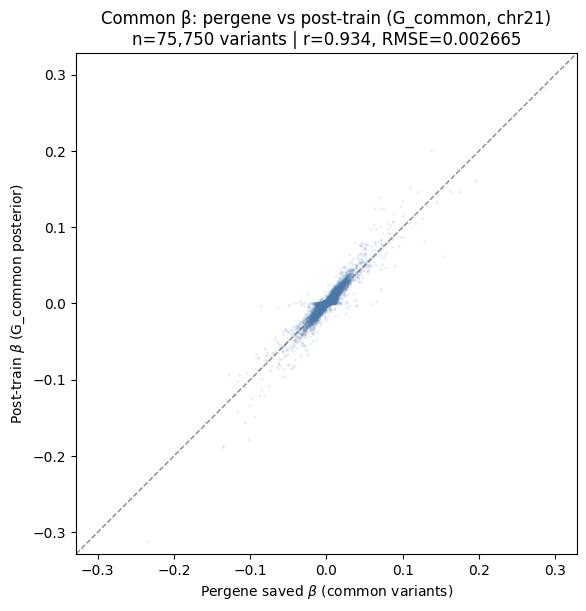

{'n_variants': 75750,
 'n_genes': 151,
 'pearson': 0.9339705733896443,
 'spearman': 0.7885679554848253,
 'rmse': 0.0026651340323230934,
 'median_abs_diff': 0.00082977630080935,
 'mean_pergene': 0.0003808819061998677,
 'mean_posterior': 0.0003724878489293055,
 'mean_diff': 8.39405727056219e-06}

In [2]:
MYOUT = "/gpfs/commons/home/vmazeeva/firvTWAS_myout"
POST_PERGENE = f"{MYOUT}/train_common01_normG_collapse/post_pergene"

# API call: common-variant scatter (genome-wide load can take a few minutes)
result = param_plots.plot_common_beta_scatter(
    POST_PERGENE,
    chromosomes=[21],          # quicker test: [21]
    max_points=500_000,        # subsample for plotting only
    plot_style="auto",         # scatter if small N, else hexbin
    show=True,
)
result["stats"]

In [3]:
import os

# Optional: save figure + inspect raw pairs
OUT_DIR = os.path.join(os.path.dirname(POST_PERGENE), "plots")
os.makedirs(OUT_DIR, exist_ok=True)

save_result = param_plots.plot_common_beta_scatter(
    POST_PERGENE,
    out_path=os.path.join(OUT_DIR, "common_beta_pergene_vs_posterior.png"),
    show=False,
)

save_result["pairs"].head()

,beta_pergene,beta_posterior,chrom,ensg,gene,panel_path,beta_diff
0,0.001326,0.000737,1,ENSG00000000457,chr1/ENSG00000000457,/gpfs/commons/home/vmazeeva/firvTWAS_myout/tra...,0.000589
1,-0.000172,-0.000009,1,ENSG00000000457,chr1/ENSG00000000457,/gpfs/commons/home/vmazeeva/firvTWAS_myout/tra...,-0.000163
2,0.001552,0.000654,1,ENSG00000000457,chr1/ENSG00000000457,/gpfs/commons/home/vmazeeva/firvTWAS_myout/tra...,0.000898
3,0.000420,0.000536,1,ENSG00000000457,chr1/ENSG00000000457,/gpfs/commons/home/vmazeeva/firvTWAS_myout/tra...,-0.000116
4,0.002136,0.000581,1,ENSG00000000457,chr1/ENSG00000000457,/gpfs/commons/home/vmazeeva/firvTWAS_myout/tra...,0.001555


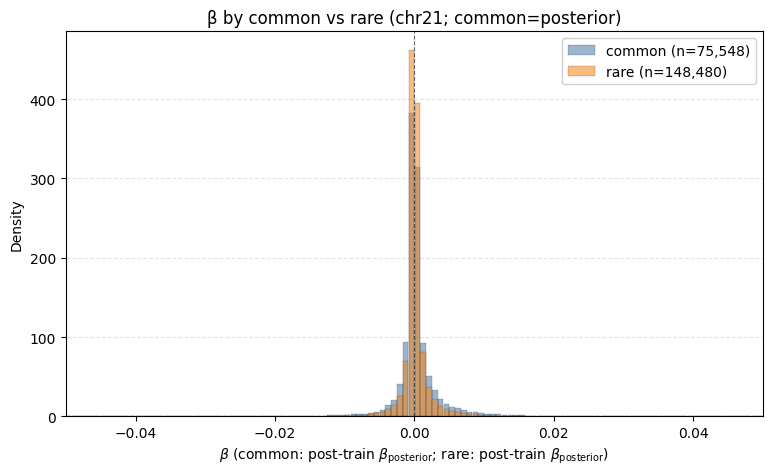

{'post_pergene_root': '/gpfs/commons/home/vmazeeva/firvTWAS_myout/train_common01_normG_collapse/post_pergene',
 'common_source': 'posterior',
 'manifest': {},
 'n_common': 75548,
 'n_rare': 148480,
 'xlabel': '$\\beta$ (common: post-train $\\beta_\\mathrm{posterior}$; rare: post-train $\\beta_\\mathrm{posterior}$)',
 'ax': <Axes: title={'center': 'β by common vs rare (chr21; common=posterior)'}, xlabel='$\\beta$ (common: post-train $\\beta_\\mathrm{posterior}$; rare: post-train $\\beta_\\mathrm{posterior}$)', ylabel='Density'>}

In [ ]:
# Full-panel β by stratum (common vs rare MAF threshold)
param_plots.plot_beta_distribution_by_stratum(
    POST_PERGENE,
    common_source="posterior",  # or "saved" for pergene beta_mean on common
    chromosomes=[21],
    show=True,
)

In [ ]:
# Saved common β only (beta_common_posterior)
param_plots.plot_saved_common_beta_distribution(
    POST_PERGENE,
    chromosomes=None,  # or [21] for a quick test
)

# Saved vs posterior distribution comparison (common variants)
param_plots.plot_common_beta_distribution_comparison(
    POST_PERGENE,
    chromosomes=None,
    posterior_col=param_plots.POSTERIOR_BETA_COL,  # G_full
)

In [ ]:
# Saved pergene β vs G_common-only posterior (needs beta_hat_common_decoupled column)
param_plots.plot_common_beta_scatter(
    POST_PERGENE,
    posterior_col=param_plots.DECOUPLED_POSTERIOR_BETA_COL,
)

# G_full vs G_common posterior on common variants (rare-coupling diagnostic)
param_plots.plot_common_posterior_scatter(POST_PERGENE, chromosomes=None, max_points=500_000)
param_plots.plot_common_posterior_distribution_comparison(POST_PERGENE, chromosomes=None)

{'train': {'split': 'train',
  'n_genes': 16220,
  'mean_r2_pergene': 0.03661593676651543,
  'mean_r2_common_only': 0.01594846703489522,
  'mean_r2_common_plus_rare': 0.0543529624773776,
  'corr_pergene_common_only': 0.693177313062037,
  'corr_pergene_common_plus_rare': 0.7865828741954864,
  'corr_common_only_common_plus_rare': 0.5124904791677815},
 'test': {'split': 'test',
  'n_genes': 16220,
  'mean_r2_pergene': 0.007118750217603131,
  'mean_r2_common_only': 0.004844670921386109,
  'mean_r2_common_plus_rare': 0.0031646635526951464,
  'corr_pergene_common_only': 0.9585343376500238,
  'corr_pergene_common_plus_rare': 0.8769644552590321,
  'corr_common_only_common_plus_rare': 0.9241102949577},
 'recommendation': 'Compare post-train r2_common_only (plain beta_hat) vs baseline_full_common01 for a fair common-only baseline match. Use r2_common_plus_rare to show the full-panel Emmental advantage (rare variants baselines did not see). Do not use pergene r2 for baseline comparison: different